## Лабораторная работа 02

## Базовый конвейер анализа данных в Pandas

ФИО: Богатырев Никита Андреевич

Группа: ЕТ-215

## Часть 1

## Формирование и сохранение исходных данных

### Задание 3.1

Создаётся словарь `raw_data`, который преобразуется в `DataFrame`. Полученная таблица выводится на экран и сохраняется в файл `online_store_orders.csv`.

In [1]:
import numpy as np
import pandas as pd

raw_data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015
    ],
    "channel": [
        "site", "app", "app", "marketplace", "site",
        "app", "site", "marketplace", "app", "site",
        "marketplace", "app", "site", "site", "marketplace"
    ],
    "order_sum": [
        1200, 2500, 1800, 3200, 900,
        1500, 2800, 45000, 2100, 1700,
        3600, 1100, 2400, 1900, 3300
    ],
    "delivery_time": [
        25, np.nan, 40, 55, 20,
        30, np.nan, 70, 35, 45,
        50, 18, 27, np.nan, 60
    ],
    "rating": [
        5, 4, 5, 3, 5,
        4, 2, 1, 5, 4,
        3, 5, 4, 5, 2
    ]
}

df = pd.DataFrame(raw_data)
print(df)
df.to_csv("online_store_orders.csv", index=False)

    order_id      channel  order_sum  delivery_time  rating
0       1001         site       1200           25.0       5
1       1002          app       2500            NaN       4
2       1003          app       1800           40.0       5
3       1004  marketplace       3200           55.0       3
4       1005         site        900           20.0       5
5       1006          app       1500           30.0       4
6       1007         site       2800            NaN       2
7       1008  marketplace      45000           70.0       1
8       1009          app       2100           35.0       5
9       1010         site       1700           45.0       4
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


## 4. Загрузка и первичный анализ данных

### Задание 4.1

Работа выполняется только с данными, загруженными из файла `online_store_orders.csv`.

In [2]:
store_df = pd.read_csv("online_store_orders.csv")

print("Первые 5 строк:")
print(store_df.head())

print("\nПоследние 5 строк:")
print(store_df.tail())

print("\nРазмер таблицы:")
print(f"строк: {store_df.shape[0]}, столбцов: {store_df.shape[1]}")

print("\nНазвания столбцов:")
print(store_df.columns.tolist())

print("\nИнформация о таблице:")
store_df.info()

Первые 5 строк:
   order_id      channel  order_sum  delivery_time  rating
0      1001         site       1200           25.0       5
1      1002          app       2500            NaN       4
2      1003          app       1800           40.0       5
3      1004  marketplace       3200           55.0       3
4      1005         site        900           20.0       5

Последние 5 строк:
    order_id      channel  order_sum  delivery_time  rating
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2

Размер таблицы:
строк: 15, столбцов: 5

Названия столбцов:
['order_id', 'channel', 'order_sum', 'delivery_time', 'rating']

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 

## 5. Выборка и фильтрация данных

### 5.1. Выбор столбцов

Столбцы `order_sum` и `delivery_time`.

### 5.2. Выбор строк

Строки с индексами от 3 до 7 включительно и столбцы `order_sum`, `delivery_time` через `iloc`. Правая граница диапазона при использовании `iloc` не включается, поэтому берётся диапазон `3:8`.

### 5.3. Фильтрация

Заказы, для которых сумма больше 2000 рублей, а рейтинг равен 5.

In [3]:
# 5.1 Выбор столбцов
print(store_df[["order_sum", "delivery_time"]])

# 5.2 Выбор строк
slice_df = store_df.iloc[3:8, [2, 3]]
print("\nСрез строк с индексом от 3 до 7:")
print(slice_df)

# 5.3 Фильтрация
premium_orders = store_df[(store_df["order_sum"] > 2000) & (store_df["rating"] == 5)]
print("\nЗаказы с суммой больше 2000 и рейтингом 5:")
print(premium_orders)

    order_sum  delivery_time
0        1200           25.0
1        2500            NaN
2        1800           40.0
3        3200           55.0
4         900           20.0
5        1500           30.0
6        2800            NaN
7       45000           70.0
8        2100           35.0
9        1700           45.0
10       3600           50.0
11       1100           18.0
12       2400           27.0
13       1900            NaN
14       3300           60.0

Срез строк с индексом от 3 до 7:
   order_sum  delivery_time
3       3200           55.0
4        900           20.0
5       1500           30.0
6       2800            NaN
7      45000           70.0

Заказы с суммой больше 2000 и рейтингом 5:
   order_id channel  order_sum  delivery_time  rating
8      1009     app       2100           35.0       5


## 6. Проверка качества данных и статистический анализ

### 6.1. Пропущенные значения

In [4]:
print(store_df.isna().sum())

order_id         0
channel          0
order_sum        0
delivery_time    3
rating           0
dtype: int64


### 6.2. Описательная статистика

In [5]:
store_df.describe()

,order_id,order_sum,delivery_time,rating
count,15.000000,15.00000,12.000000,15.000000
mean,1008.000000,5000.00000,39.583333,3.800000
std,4.472136,11096.33144,16.654010,1.320173
min,1001.000000,900.00000,18.000000,1.000000
25%,1004.500000,1600.00000,26.500000,3.000000
50%,1008.000000,2100.00000,37.500000,4.000000
75%,1011.500000,3000.00000,51.250000,5.000000
max,1015.000000,45000.00000,70.000000,5.000000


### 6.3. Среднее и медиана

In [6]:
mean_delivery = store_df["delivery_time"].mean()
median_delivery = store_df["delivery_time"].median()
print("Среднее:", mean_delivery)
print("Медиана:", median_delivery)

Среднее: 39.583333333333336
Медиана: 37.5


### 6.4. Распределение рейтингов

In [7]:
store_df["rating"].value_counts()

rating
5    6
4    4
3    2
2    2
1    1
Name: count, dtype: int64

## 7. Группировка и получение аналитического результата

### 7.1. Создание производного признака

Признак `is_high_value` равен `True`, когда сумма заказа больше 3000 рублей.

In [8]:
store_df["is_high_value"] = store_df["order_sum"] > 3000
store_df[["order_id", "order_sum", "is_high_value"]]

,order_id,order_sum,is_high_value
0,1001,1200,False
1,1002,2500,False
2,1003,1800,False
3,1004,3200,True
4,1005,900,False
5,1006,1500,False
6,1007,2800,False
7,1008,45000,True
8,1009,2100,False
9,1010,1700,False


### 7.2. Группировка по каналу продаж

Средняя сумма заказа для каждого канала продаж.

### 7.3. Сортировка результата

In [9]:
channel_stats = store_df.groupby("channel")["order_sum"].mean()
print("Средняя сумма заказа по каналам продаж:")
print(channel_stats)

channel_stats = channel_stats.sort_values(ascending=False)
print("\nОтсортировано по убыванию:")
print(channel_stats)

Средняя сумма заказа по каналам продаж:
channel
app             1800.000000
marketplace    13775.000000
site            1816.666667
Name: order_sum, dtype: float64

Отсортировано по убыванию:
channel
marketplace    13775.000000
site            1816.666667
app             1800.000000
Name: order_sum, dtype: float64


## 8. Итоговый аналитический вывод

Итоговый аналитический вывод подставляется после оформления отчёта.

## 11. Дополнительное задание

Гистограмма распределения суммы заказов.

<Axes: ylabel='Frequency'>

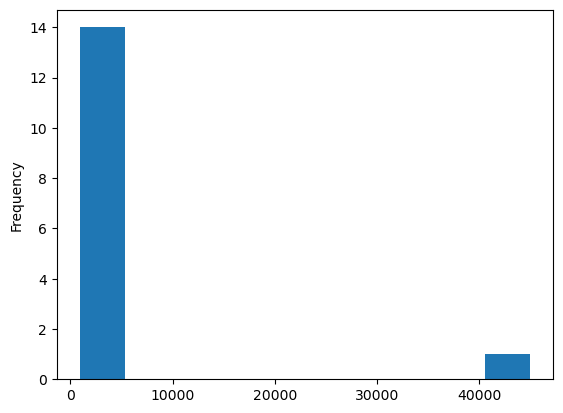

In [10]:
store_df["order_sum"].plot(kind="hist")